In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split
from sklearn.metrics import confusion_matrix
import seaborn as sns 
from matplotlib.ticker import MaxNLocator

In [2]:
MODEL_NAME = "clf_3"
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.ToTensor()

full_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_data, val_data = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


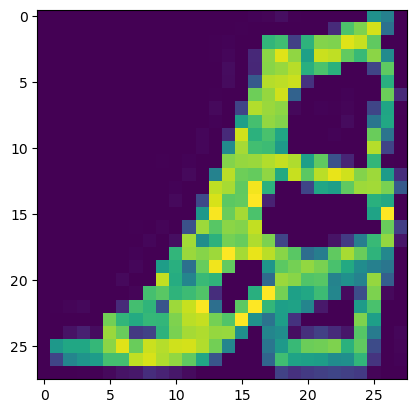

In [6]:
image = images[0]
image = image.permute(1, 2, 0)
plt.imshow(image)

In [7]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 3 x 3
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(128*3*3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
def save_checkpoint(model, optimizer, epoch, filename="checkpoint.pth"):
    
    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict()
    }
    
    torch.save(checkpoint, filename)

In [9]:
model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [10]:
num_epoch = []
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):

    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_losses.append(train_loss)
    train_acc = train_correct / train_total
    train_accs.append(train_acc)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            val_loss += loss.item() * images.size(0)

            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, filename=f"{MODEL_NAME}_best.pth")

    num_epoch.append(epoch)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] " f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | " f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch [1/20] Train Loss: 0.6775 | Train Acc: 74.86% | Val Loss: 0.4168 | Val Acc: 84.73%
Epoch [2/20] Train Loss: 0.4328 | Train Acc: 84.02% | Val Loss: 0.3439 | Val Acc: 87.47%
Epoch [3/20] Train Loss: 0.3801 | Train Acc: 85.99% | Val Loss: 0.3297 | Val Acc: 87.42%
Epoch [4/20] Train Loss: 0.3491 | Train Acc: 87.11% | Val Loss: 0.2917 | Val Acc: 89.17%
Epoch [5/20] Train Loss: 0.3263 | Train Acc: 87.97% | Val Loss: 0.2827 | Val Acc: 89.83%
Epoch [6/20] Train Loss: 0.3100 | Train Acc: 88.58% | Val Loss: 0.2696 | Val Acc: 90.12%
Epoch [7/20] Train Loss: 0.2960 | Train Acc: 89.09% | Val Loss: 0.2621 | Val Acc: 90.37%
Epoch [8/20] Train Loss: 0.2861 | Train Acc: 89.46% | Val Loss: 0.2533 | Val Acc: 90.77%
Epoch [9/20] Train Loss: 0.2721 | Train Acc: 89.82% | Val Loss: 0.2474 | Val Acc: 90.85%
Epoch [10/20] Train Loss: 0.2674 | Train Acc: 90.04% | Val Loss: 0.2413 | Val Acc: 90.80%
Epoch [11/20] Train Loss: 0.2563 | Train Acc: 90.36% | Val Loss: 0.2393 | Val Acc: 91.45%
Epoch [12/20] Train

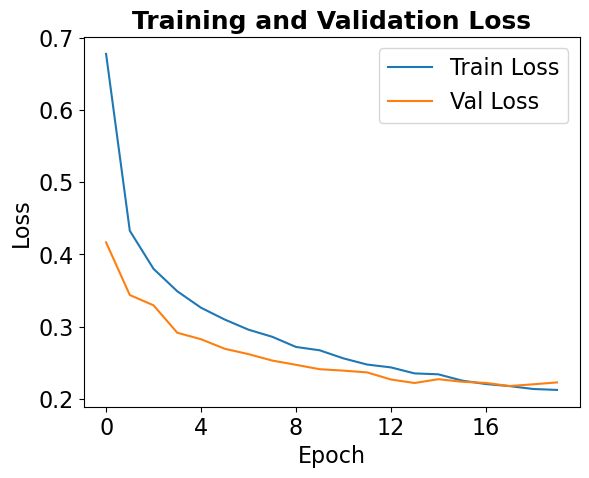

In [26]:
# Loss vs Epoch Plot

plt.plot(num_epoch, train_losses, label="Train Loss")
plt.plot(num_epoch, val_losses, label="Val Loss")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.title("Training and Validation Loss", fontsize=18, fontweight="bold")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.savefig("train_val_loss.pdf", bbox_inches="tight")
plt.show()

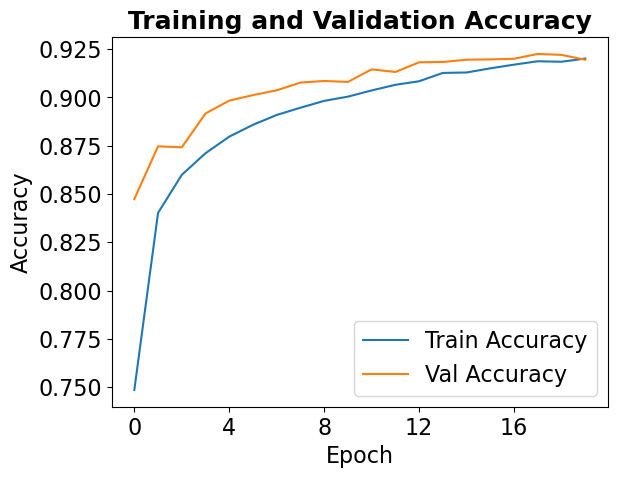

In [27]:
# Accuracy vs Epoch Plot

plt.plot(num_epoch, train_accs, label="Train Accuracy")
plt.plot(num_epoch, val_accs, label="Val Accuracy")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.title("Training and Validation Accuracy", fontsize=18, fontweight="bold")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.savefig("train_val_acc.pdf", bbox_inches="tight")
plt.show()